# 02 — Flash Responses (Optic Lobe mcHH)

Full-field flash stimulus applied to the right optic-lobe multi-compartment
network.  Analysis:
- Population and single-neuron traces by type
- Flash Response Index (ON vs OFF preference)
- ON / OFF / Motion pathway decomposition
- **LC neuron** responses

### Timing
| Dataset | 200ms sim | 500ms sim |
|---------|-----------|----------|
| Motion subset (26K) | ~19s | ~48s |
| Full right OL (47K) | ~58s | ~145s |

In [1]:
import sys, time, logging
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, '../..')
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

from neuro_framework.models.fafb_mc_network import FAFBMCNetwork

In [2]:
# Use full OL to include LC neurons.  Switch to motion subset for speed.
DATA_DIR = '../../mcHH/data/optic_lobe_right'
# DATA_DIR = '../../mcHH/data/optic_lobe_right_motion'  # fast but no LC

SWC_PATH  = '../../mcHH/data/generic_2comp.swc'
ION_RULES = '../data/fafb_ion_channel_rules.csv'
SYN_RULES = '../data/fafb_synapse_rules.csv'

DT = 0.1
net = FAFBMCNetwork.from_preprocessed(
    data_dir=DATA_DIR, swc_path=SWC_PATH,
    ion_rules_path=ION_RULES, syn_rules_path=SYN_RULES,
    ncomp=2, min_syn_count=3, dt=DT,
)
print(net)

INFO Loaded CSVs in 0.5s
INFO Mapped 1111323 edges in 0.6s
INFO Synapse lookup done in 3.8s
INFO FAFBMCNetwork: 47291 neurons (2 comp each), 1111323 edges, 4751 photoreceptors [3.8s]


FAFBMCNetwork(n_neurons=47291, n_comp=2, n_edges=1111323, n_photo=4751, trainable=5840363)


## 1. Flash stimulus

In [3]:
I_AMP = 30.0
T_PRE, T_ON, T_OFF = 50.0, 100.0, 50.0
T_TOTAL = T_PRE + T_ON + T_OFF
T_steps = int(T_TOTAL / DT)

n_photo = net.input_mask.sum().item()
x = torch.zeros(1, T_steps, n_photo)
t_on_s = int(T_PRE / DT)
t_on_e = int((T_PRE + T_ON) / DT)
x[:, t_on_s:t_on_e, :] = I_AMP

print(f'Stimulus: {T_steps} steps ({T_TOTAL:.0f}ms), {n_photo} photoreceptors')

Stimulus: 2000 steps (200ms), 4751 photoreceptors


In [4]:
with torch.no_grad():
    V = net(x, dt=DT, show_progress=True)
print(f'V range: [{V.min():.1f}, {V.max():.1f}], NaN={torch.isnan(V).any().item()}')

/Users/lengyuner/anaconda3/envs/comp_neuro/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Sim 47291N/1111323E: 100%|██████████| 2000/2000 [01:00<00:00, 33.23step/s]


V range: [-69.0, -24.7], NaN=False


## 2. Population-mean traces

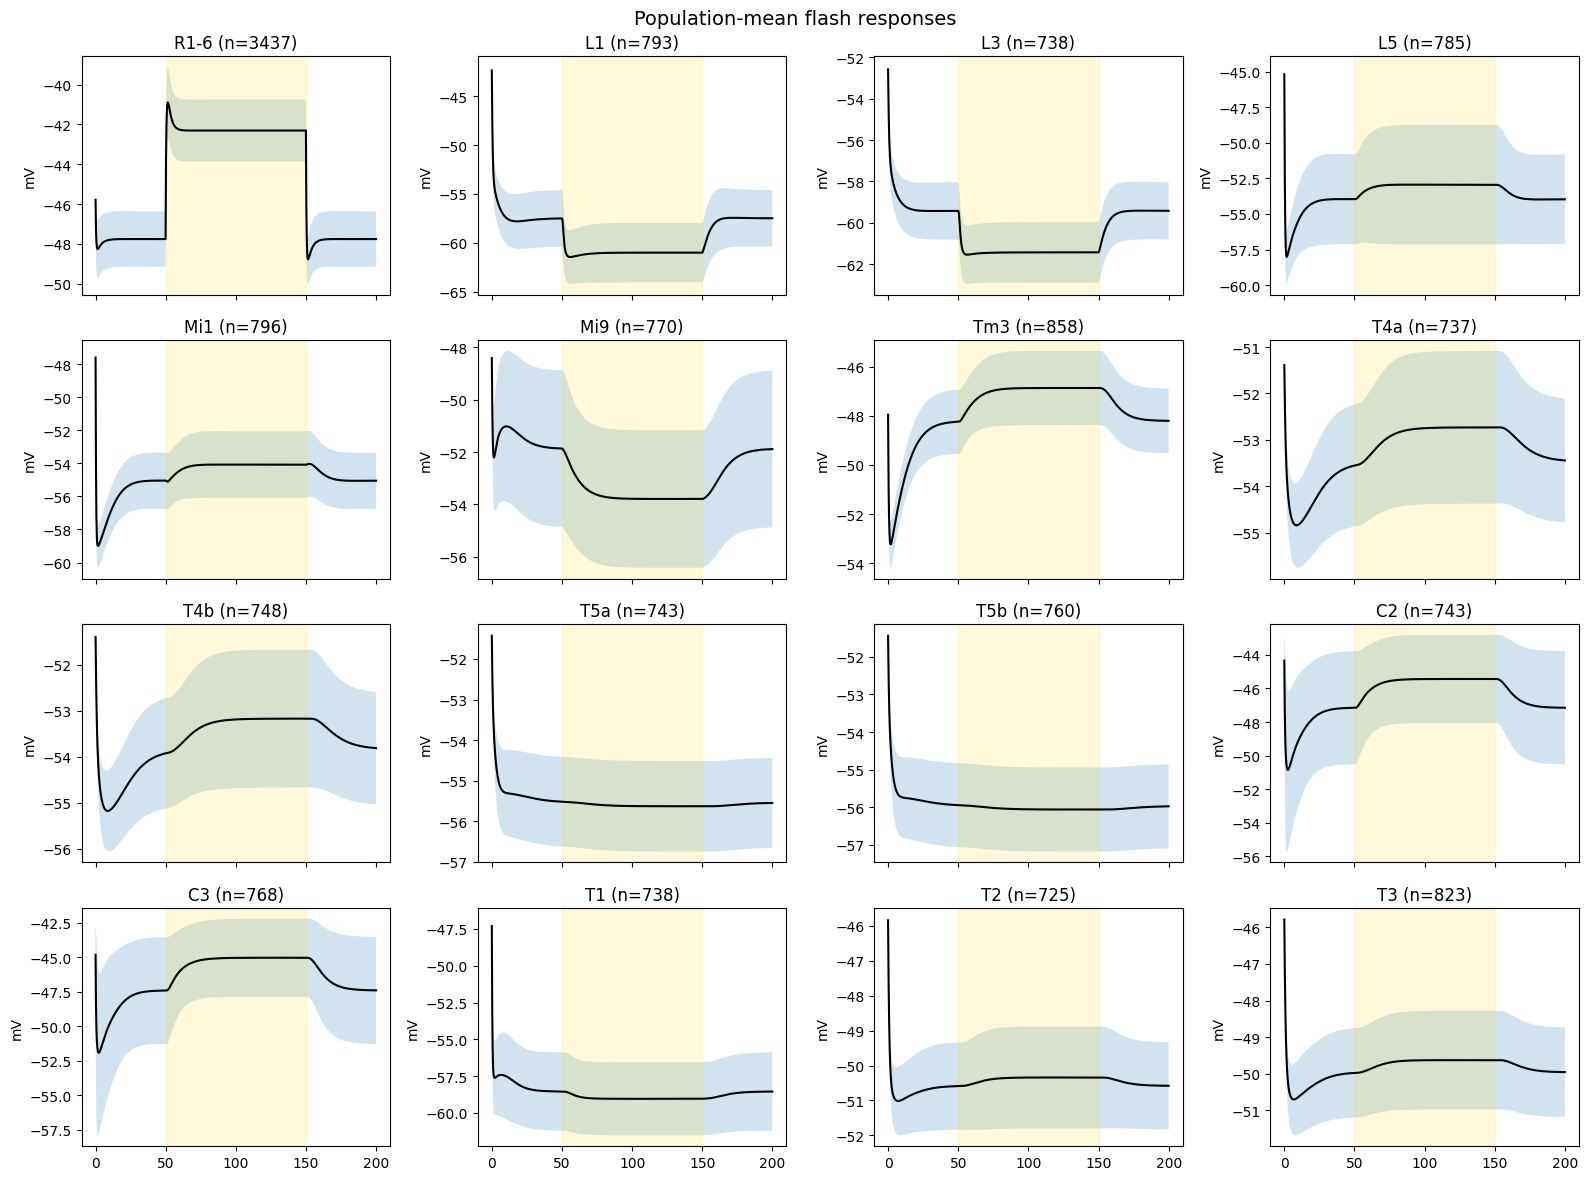

In [5]:
pathway = ['R1-6', 'L1', 'L3', 'L5', 'Mi1', 'Mi9', 'Tm3',
           'T4a', 'T4b', 'T5a', 'T5b', 'C2', 'C3', 'T1', 'T2', 'T3']
t_ms = np.arange(V.shape[1]) * DT

fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True)
for i, ct in enumerate(pathway):
    ax = axes.flat[i]
    idx = net.get_indices_by_type(ct)
    if not idx:
        ax.set_title(f'{ct} (n=0)'); continue
    v_m = V[0, :, idx].mean(dim=1).numpy()
    v_s = V[0, :, idx].std(dim=1).numpy()
    ax.plot(t_ms, v_m, 'k', lw=1.5)
    ax.fill_between(t_ms, v_m-v_s, v_m+v_s, alpha=0.2)
    ax.axvspan(T_PRE, T_PRE+T_ON, color='gold', alpha=0.15)
    ax.set_title(f'{ct} (n={len(idx)})')
    ax.set_ylabel('mV')
fig.suptitle('Population-mean flash responses', fontsize=14)
plt.tight_layout(); plt.show()

## 3. Single-neuron traces

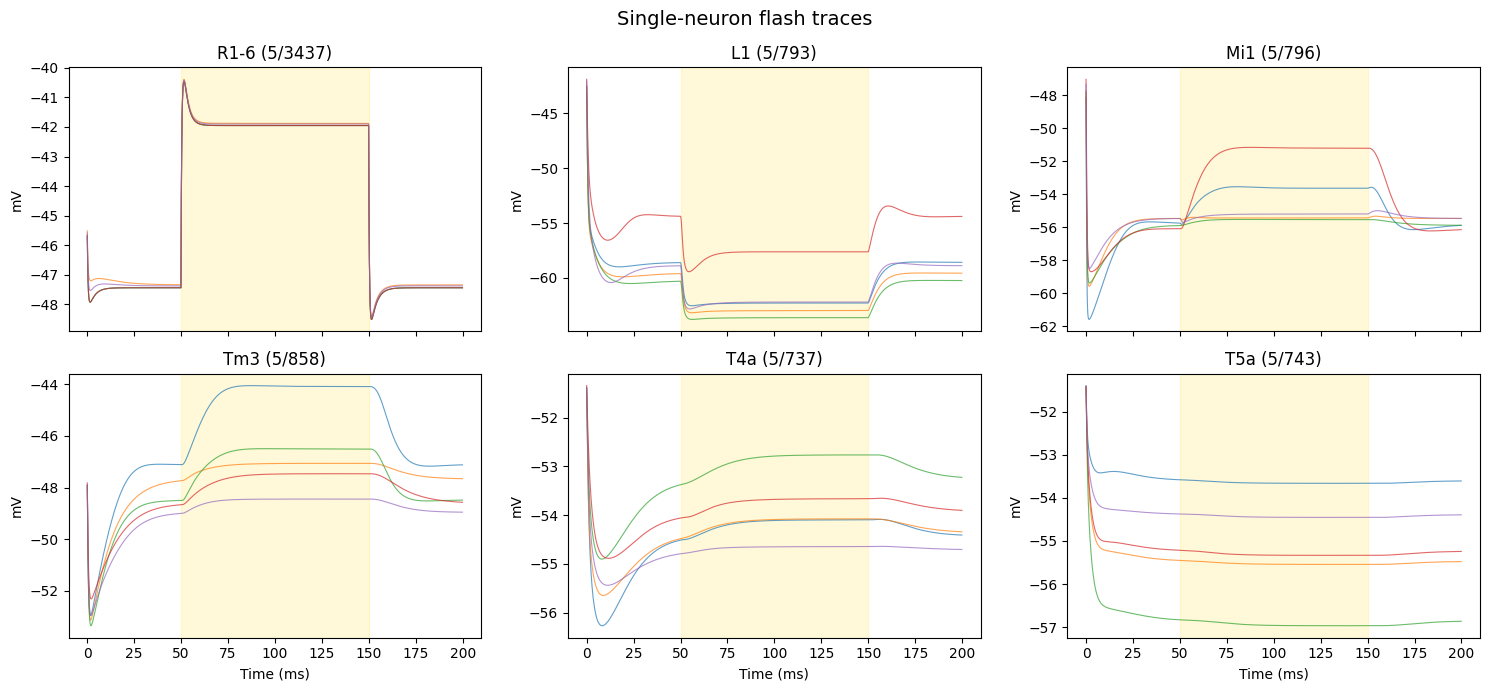

In [6]:
show_types = ['R1-6', 'L1', 'Mi1', 'Tm3', 'T4a', 'T5a']
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for ax, ct in zip(axes.flat, show_types):
    idx = net.get_indices_by_type(ct)
    if not idx: ax.set_title(f'{ct} (n=0)'); continue
    for j in range(min(5, len(idx))):
        ax.plot(t_ms, V[0, :, idx[j]].numpy(), lw=0.8, alpha=0.7)
    ax.axvspan(T_PRE, T_PRE+T_ON, color='gold', alpha=0.15)
    ax.set_title(f'{ct} ({min(5,len(idx))}/{len(idx)})')
    ax.set_ylabel('mV')
for ax in axes[-1]: ax.set_xlabel('Time (ms)')
fig.suptitle('Single-neuron flash traces', fontsize=14)
plt.tight_layout(); plt.show()

## 4. Flash Response Index (FRI)

    Type      n         FRI      R_on     R_off
    R1-6   3437  +0.996    +5.525    -0.030
      L1    793  -0.711    -3.869    -0.664
      L3    738  -0.621    -2.314    -0.540
      L5    785  +0.145    +1.590    +0.852
     Mi1    796  +0.161    +1.727    +1.083
     Mi9    770  -0.376    -2.040    -0.941
     Tm3    858  +0.178    +2.481    +1.682
     T4a    737  +0.100    +1.206    +0.949
     T4b    748  +0.091    +1.128    +0.904
     T5a    743  -0.024    -0.338    -0.322
     T5b    760  -0.023    -0.349    -0.334
      C2    743  +0.246    +2.406    +1.364
      C3    768  +0.262    +3.210    +1.754
      T1    738  -0.130    -0.944    -0.670
      T2    725  +0.129    +0.278    +0.169
      T3    823  +0.155    +0.491    +0.350


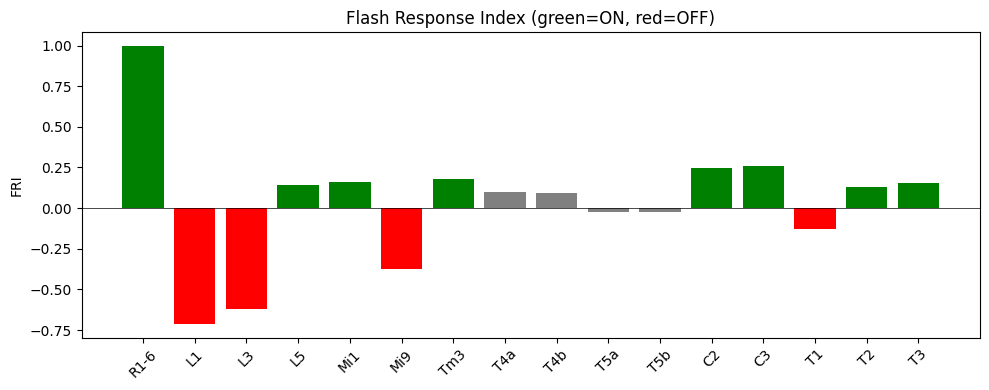

In [7]:
v_base = V[0, :t_on_s, :].mean(dim=0)
r_on  = V[0, t_on_s:t_on_e, :].mean(dim=0) - v_base
r_off = V[0, t_on_e:, :].mean(dim=0) - v_base
fri = (r_on - r_off) / (r_on.abs() + r_off.abs() + 1e-8)

print(f'{"Type":>8s}  {"n":>5s}  {"FRI":>10s}  {"R_on":>8s}  {"R_off":>8s}')
fri_data = []
for ct in pathway:
    idx = net.get_indices_by_type(ct)
    if not idx: continue
    it = torch.tensor(idx)
    f = fri[it].mean().item()
    fri_data.append((ct, len(idx), f))
    print(f'{ct:>8s}  {len(idx):5d}  {f:+.3f}  '
          f'{r_on[it].mean():+8.3f}  {r_off[it].mean():+8.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
labels = [d[0] for d in fri_data]
vals = [d[2] for d in fri_data]
colors = ['green' if v > 0.1 else 'red' if v < -0.1 else 'gray' for v in vals]
ax.bar(range(len(labels)), vals, color=colors)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('FRI'); ax.set_title('Flash Response Index (green=ON, red=OFF)')
plt.tight_layout(); plt.show()

## 5. ON / OFF / Motion pathway comparison

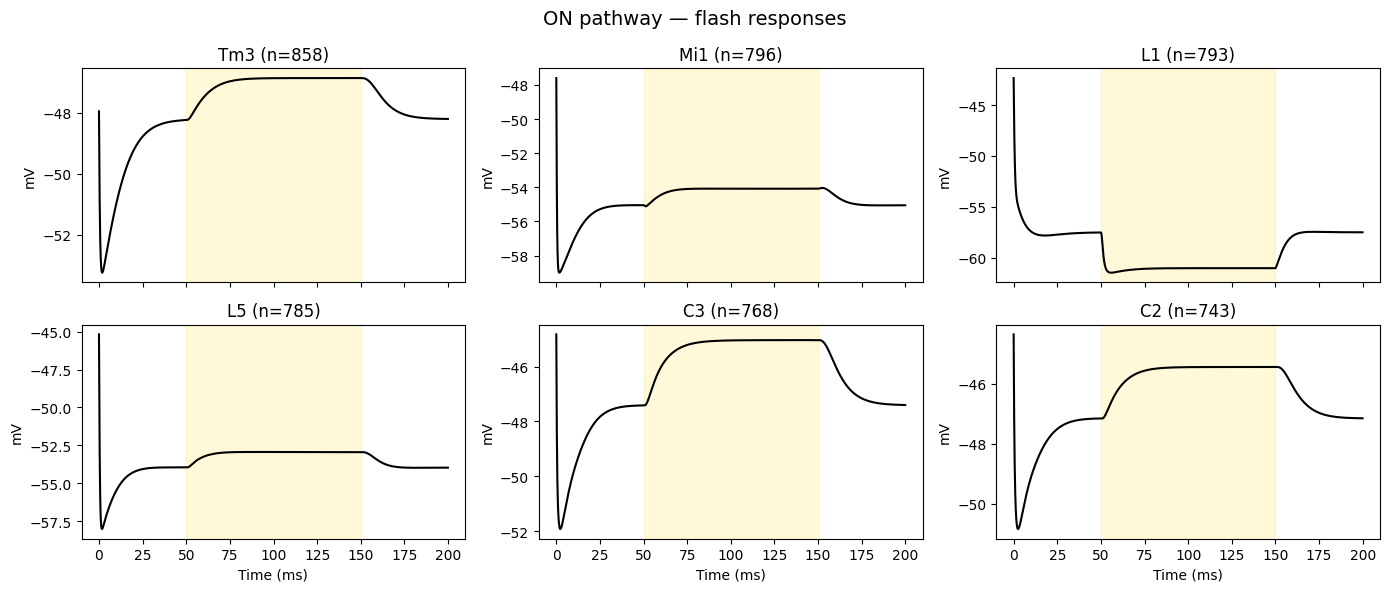

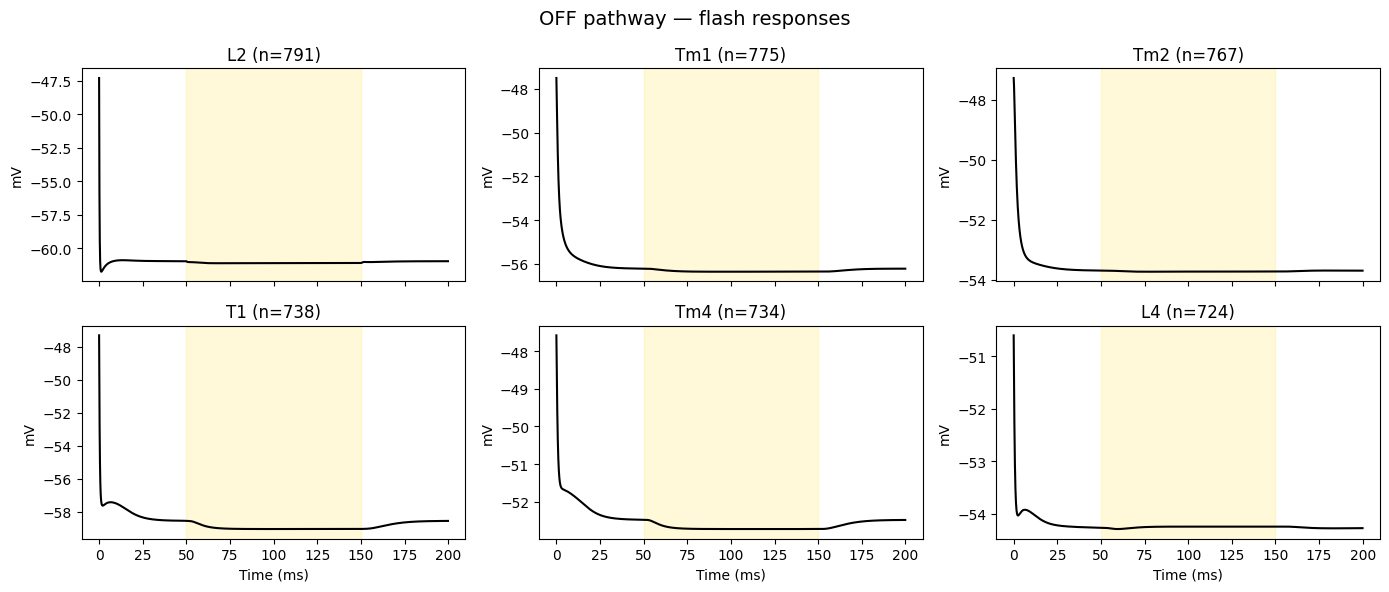

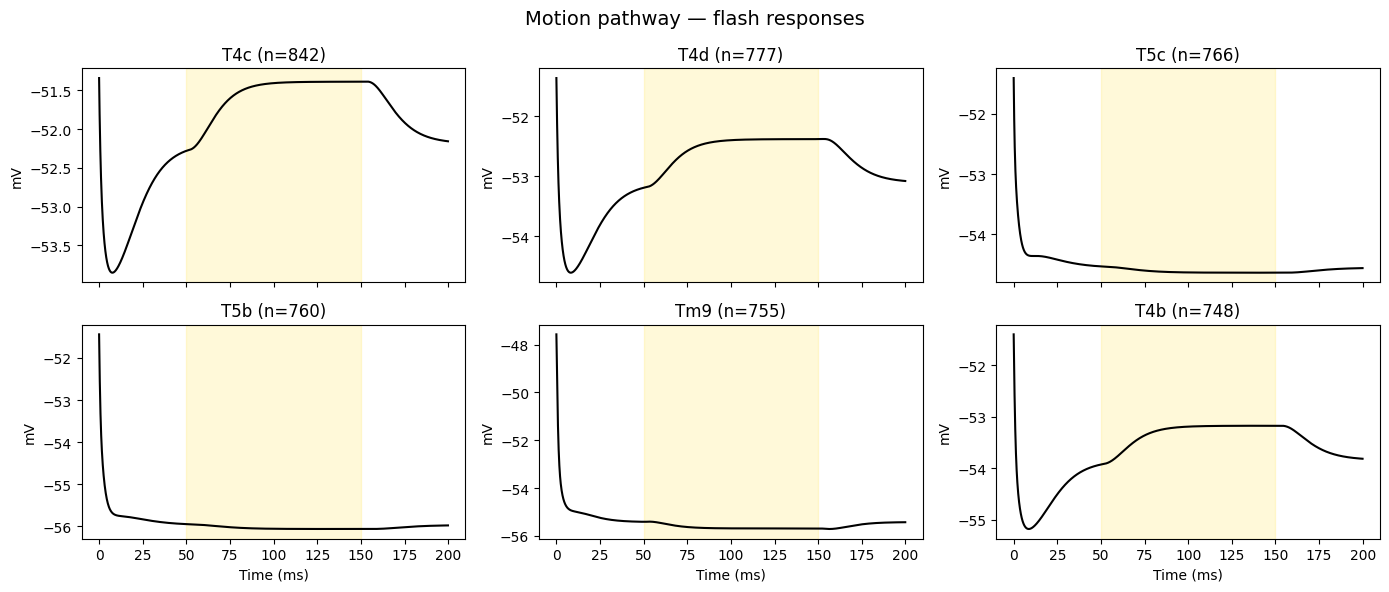

In [8]:
neurons_df = pd.read_csv(DATA_DIR + '/neurons.csv')
all_ids = np.sort(neurons_df['root_id'].unique())
id_to_idx = {int(r): i for i, r in enumerate(all_ids)}
neurons_df['idx'] = neurons_df['root_id'].map(id_to_idx)

for subsys in ['ON', 'OFF', 'Motion']:
    sub = neurons_df[neurons_df['subsystem'] == subsys]
    if len(sub) == 0: continue
    top_types = sub['type'].value_counts().head(6).index.tolist()
    fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
    for ax, ct in zip(axes.flat, top_types):
        il = sub[sub['type']==ct]['idx'].dropna().astype(int).tolist()
        if not il: ax.set_title(f'{ct} (0)'); continue
        ax.plot(t_ms, V[0,:,il].mean(dim=1).numpy(), 'k', lw=1.5)
        ax.axvspan(T_PRE, T_PRE+T_ON, color='gold', alpha=0.15)
        ax.set_title(f'{ct} (n={len(il)})')
        ax.set_ylabel('mV')
    for ax in axes[-1]: ax.set_xlabel('Time (ms)')
    fig.suptitle(f'{subsys} pathway — flash responses', fontsize=14)
    plt.tight_layout(); plt.show()

## 6. LC neuron responses

LC types found: 52, total neurons: 1917


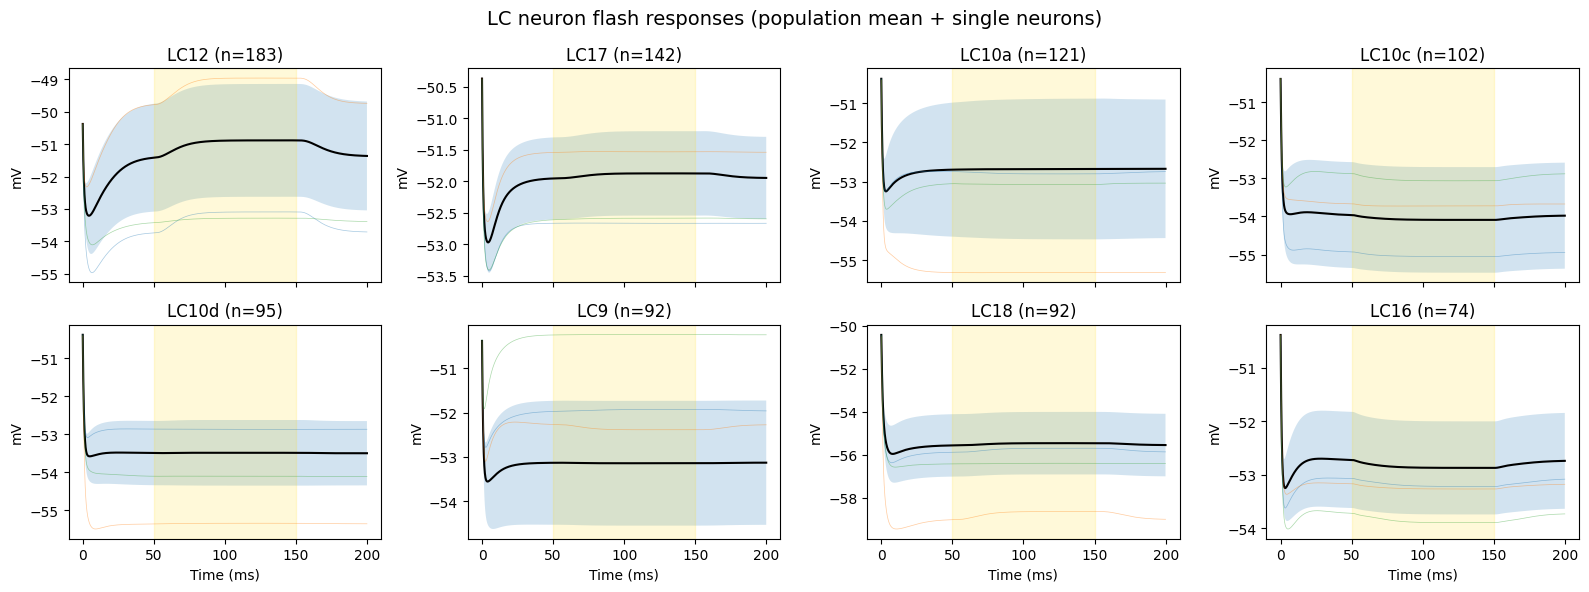

In [9]:
lc_mask = neurons_df['type'].str.startswith('LC', na=False)
lc_types = neurons_df.loc[lc_mask, 'type'].value_counts()
print(f'LC types found: {len(lc_types)}, total neurons: {lc_mask.sum()}')

if len(lc_types) == 0:
    print('No LC neurons — use full OL dataset.'); raise SystemExit

top_lc = lc_types.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True)
for ax, ct in zip(axes.flat, top_lc):
    il = neurons_df.loc[neurons_df['type']==ct, 'idx'].dropna().astype(int).tolist()
    if not il: ax.set_title(f'{ct} (0)'); continue
    v_m = V[0,:,il].mean(dim=1).numpy()
    v_s = V[0,:,il].std(dim=1).numpy()
    ax.plot(t_ms, v_m, 'k', lw=1.5)
    ax.fill_between(t_ms, v_m-v_s, v_m+v_s, alpha=0.2)
    for j in range(min(3, len(il))):
        ax.plot(t_ms, V[0,:,il[j]].numpy(), lw=0.5, alpha=0.4)
    ax.axvspan(T_PRE, T_PRE+T_ON, color='gold', alpha=0.15)
    ax.set_title(f'{ct} (n={len(il)})')
    ax.set_ylabel('mV')
for ax in axes[-1]: ax.set_xlabel('Time (ms)')
fig.suptitle('LC neuron flash responses (population mean + single neurons)', fontsize=14)
plt.tight_layout(); plt.show()

   LC Type     n       FRI      R_on     R_off
      LC12   183  +0.094    +1.070    +0.881
      LC17   142  +0.023    +0.316    +0.297
     LC10a   121  -0.064    +0.123    +0.130
     LC10c   102  -0.193    -0.211    -0.160
     LC10d    95  +0.052    -0.035    -0.042
       LC9    92  -0.072    +0.059    +0.063
      LC18    92  -0.030    +0.088    +0.068
      LC16    74  -0.609    -0.073    -0.012
      LC13    70  -0.021    +0.140    +0.143
      LC21    62  -0.032    +0.149    +0.136
      LC11    61  +0.043    +0.281    +0.250
       LC6    60  -0.250    -0.085    -0.063
     LC28a    56  +0.090    -0.216    -0.219
      LC15    54  -0.093    -0.046    -0.040
     LC10e    51  +0.010    +0.072    +0.073


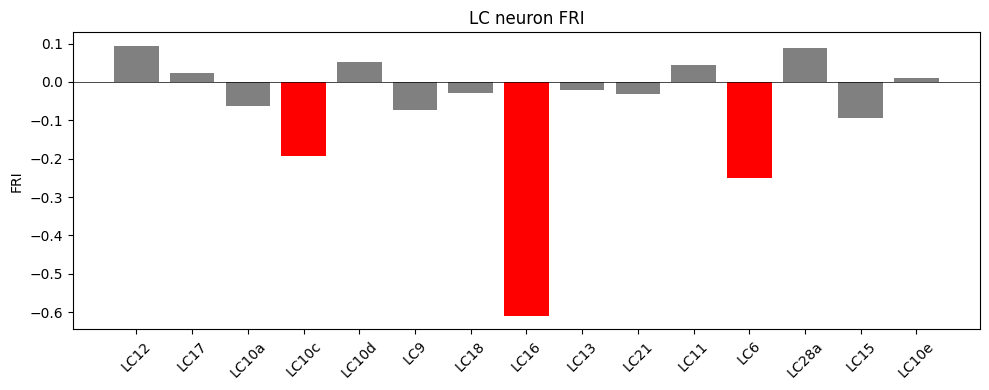

In [10]:
# FRI for LC neurons
print(f'{"LC Type":>10s}  {"n":>4s}  {"FRI":>8s}  {"R_on":>8s}  {"R_off":>8s}')
lc_fri = []
for ct in lc_types.head(15).index:
    il = neurons_df.loc[neurons_df['type']==ct, 'idx'].dropna().astype(int).tolist()
    if not il: continue
    it = torch.tensor(il)
    f = fri[it].mean().item()
    lc_fri.append((ct, len(il), f))
    print(f'{ct:>10s}  {len(il):4d}  {f:+.3f}  '
          f'{r_on[it].mean():+8.3f}  {r_off[it].mean():+8.3f}')

if lc_fri:
    fig, ax = plt.subplots(figsize=(10, 4))
    labels = [d[0] for d in lc_fri]
    vals = [d[2] for d in lc_fri]
    colors = ['green' if v>0.1 else 'red' if v<-0.1 else 'gray' for v in vals]
    ax.bar(range(len(labels)), vals, color=colors)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('FRI'); ax.set_title('LC neuron FRI')
    plt.tight_layout(); plt.show()